# Fine-tuning україномовної трансформерної моделі для класифікації спаму

У цьому ноутбуці реалізовано повний пайплайн навчання BERT-подібної моделі для задачі бінарної класифікації спаму.

За базову модель обрано `youscan/ukr-roberta-base` — україномовну RoBERTa-base модель на 12 шарах, 768 hidden size і приблизно 125M параметрів. Для задач класифікації тексту Hugging Face рекомендує використовувати `AutoTokenizer`, `AutoModelForSequenceClassification` і `Trainer`.

Ноутбук містить:
- завантаження та перевірку даних;
- train/validation/test split;
- токенізацію;
- fine-tuning через `Trainer`;
- оцінку моделі;
- збереження моделі й токенізатора;
- приклади inference;
- блок для error analysis.

## 1. Встановлення залежностей

Запустити цю комірку, якщо потрібні бібліотеки ще не встановлені.

In [1]:
%pip install -q transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.1 MB/s eta 0:00:00


## 2. Імпорт бібліотек

In [2]:
import os
import re
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from datasets import Dataset, DatasetDict
import evaluate

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

## 3. Конфігурація

In [22]:
RANDOM_STATE = 42

DATA_PATH = Path("/content/drive/MyDrive/spam_project/spam.csv")   # заміни на свій шлях
TEXT_COL = "text"
TARGET_COL = "spam"

MODEL_NAME = "youscan/ukr-roberta-base"
MAX_LENGTH = 128

OUTPUT_DIR = Path("/content/drive/MyDrive/spam_project/bert_artifacts")
OUTPUT_DIR.mkdir(exist_ok=True)

set_seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

## 4. Перевірка доступності GPU

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Навчання буде виконуватись на CPU")

Device: cuda
GPU: Tesla T4


## 5. Завантаження та базова підготовка даних

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
display(df.head())

required_columns = {TEXT_COL, TARGET_COL}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"У датасеті відсутні обов'язкові колонки: {missing_columns}")

df = df[[TEXT_COL, TARGET_COL]].copy()
df.rename(columns={TEXT_COL: "text", TARGET_COL: "label"}, inplace=True)

df["text"] = df["text"].astype(str).apply(lambda x: re.sub(r"\s+", " ", x).strip())
df = df[df["text"].str.len() > 0].copy()

unique_labels = sorted(df["label"].dropna().unique().tolist())
if set(unique_labels) - {0, 1}:
    raise ValueError(f"Очікувались мітки 0/1, але знайдено: {unique_labels}")

print("\nПропуски:")
display(df.isna().sum())

print("\nРозподіл класів:")
display(df["label"].value_counts(normalize=True).sort_index())

Shape: (91386, 2)


,text,spam
0,"__USER__ Це лека, і вона дуже крута, вона наша...",0
1,"У другому турі підтримав Віктора Ющенка, поста...",0
2,🪖 Твоя ідеальна підробітка? Знайдена. Без босі...,1
3,🔹 ВАКАНСІЯ | АДМІНІСТРАТОР у центрі протезуван...,1
4,__USER__ Відміть мене коли зможеш,0



Пропуски:


,0
text,0
label,0



Розподіл класів:


,proportion
label,
0,0.713074
1,0.286926


## 6. Train / Validation / Test split

Виділяємо:
- train для навчання,
- validation для контролю під час fine-tuning,
- test для фінальної оцінки.

In [7]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df["label"],
)

train_df, valid_df = train_test_split(
    train_df,
    test_size=0.1,
    random_state=RANDOM_STATE,
    stratify=train_df["label"],
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", train_df.shape)
print("Valid:", valid_df.shape)
print("Test :", test_df.shape)

print("\nTrain distribution:")
display(train_df["label"].value_counts(normalize=True).sort_index())

print("\nValid distribution:")
display(valid_df["label"].value_counts(normalize=True).sort_index())

print("\nTest distribution:")
display(test_df["label"].value_counts(normalize=True).sort_index())

Train: (65797, 2)
Valid: (7311, 2)
Test : (18278, 2)

Train distribution:


,proportion
label,
0,0.713072
1,0.286928



Valid distribution:


,proportion
label,
0,0.713035
1,0.286965



Test distribution:


,proportion
label,
0,0.713098
1,0.286902


## 7. Перетворення в Hugging Face Dataset

In [8]:
dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df[["text", "label"]], preserve_index=False),
    "validation": Dataset.from_pandas(valid_df[["text", "label"]], preserve_index=False),
    "test": Dataset.from_pandas(test_df[["text", "label"]], preserve_index=False),
})

dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 65797
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 7311
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 18278
    })
})

## 8. Завантаження токенізатора

In [9]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

RobertaTokenizer(name_or_path='youscan/ukr-roberta-base', vocab_size=52000, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("<mask>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

## 9. Токенізація

Для трансформерних моделей не потрібно робити агресивну ручну очистку тексту.
Зазвичай достатньо подати майже сирий текст, а розбиття на токени виконує токенізатор моделі.

In [10]:
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

tokenized_dataset = dataset.map(tokenize_batch, batched=True)
tokenized_dataset

Map:   0%|          | 0/65797 [00:00<?, ? examples/s]

Map:   0%|          | 0/7311 [00:00<?, ? examples/s]

Map:   0%|          | 0/18278 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 65797
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 7311
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 18278
    })
})

## 10. Data collator

Використовуємо динамічний padding, щоб не паддити всі тексти до однакової максимальної довжини наперед.

In [11]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

## 11. Метрики

In [12]:
accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
    preds = np.argmax(logits, axis=1)

    metrics = {
        "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "precision": precision_metric.compute(predictions=preds, references=labels)["precision"],
        "recall": recall_metric.compute(predictions=preds, references=labels)["recall"],
        "f1": f1_metric.compute(predictions=preds, references=labels)["f1"],
        "roc_auc": roc_auc_score(labels, probs[:, 1]),
    }
    return metrics

## 12. Завантаження моделі класифікації

In [13]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "ham", 1: "spam"},
    label2id={"ham": 0, "spam": 1},
)
model.config

pytorch_model.bin:   0%|          | 0.00/507M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/507M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: youscan/ukr-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaConfig {
  "add_cross_attention": false,
  "architectures": [
    "RobertaForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "ham",
    "1": "spam"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": {
    "ham": 0,
    "spam": 1
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 514,
  "model_type": "roberta",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 1,
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "type_vocab_size": 1,
  "use_cache": true,
  "vocab_size": 52000
}

## 13. Параметри навчання

Стартовий конфіг для baseline fine-tuning:
- `learning_rate=2e-5`
- `num_train_epochs=3`
- `batch_size=8`
- `weight_decay=0.01`

In [14]:
training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR / "checkpoints"),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=RANDOM_STATE,
)

## 14. Trainer

In [15]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

## 15. Навчання моделі

In [16]:
train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.041633,0.020239,0.996580,0.998557,0.989514,0.994015,0.999098
2,0.011376,0.023503,0.996444,0.995694,0.991897,0.993792,0.999488
3,0.003640,0.017854,0.997264,0.998082,0.992374,0.995220,0.999611


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=24675, training_loss=0.01888298196995512, metrics={'train_runtime': 2170.6876, 'train_samples_per_second': 90.935, 'train_steps_per_second': 11.367, 'total_flos': 1.066955978087298e+16, 'train_loss': 0.01888298196995512, 'epoch': 3.0})

## 16. Оцінка на validation і test

In [17]:
valid_metrics = trainer.evaluate(tokenized_dataset["validation"])
test_metrics = trainer.evaluate(tokenized_dataset["test"])

print("Validation metrics:")
display(valid_metrics)

print("Test metrics:")
display(test_metrics)

Validation metrics:


{'eval_loss': 0.017853660508990288,
 'eval_accuracy': 0.9972643961154425,
 'eval_precision': 0.9980824544582934,
 'eval_recall': 0.9923736892278361,
 'eval_f1': 0.9952198852772467,
 'eval_roc_auc': 0.999611177746036,
 'eval_runtime': 15.5816,
 'eval_samples_per_second': 469.207,
 'eval_steps_per_second': 58.659,
 'epoch': 3.0}

Test metrics:


{'eval_loss': 0.03299044817686081,
 'eval_accuracy': 0.9954590217748113,
 'eval_precision': 0.9948226270373921,
 'eval_recall': 0.9893211289092296,
 'eval_f1': 0.9920642508844058,
 'eval_roc_auc': 0.9997412666654728,
 'eval_runtime': 44.8653,
 'eval_samples_per_second': 407.397,
 'eval_steps_per_second': 50.93,
 'epoch': 3.0}

## 17. Детальний аналіз test-передбачень

In [18]:
pred_output = trainer.predict(tokenized_dataset["test"])

test_logits = pred_output.predictions
test_labels = pred_output.label_ids
test_probs = torch.softmax(torch.tensor(test_logits), dim=1).numpy()
test_preds = np.argmax(test_logits, axis=1)

print(classification_report(test_labels, test_preds, target_names=["ham", "spam"], digits=4))

              precision    recall  f1-score   support

         ham     0.9957    0.9979    0.9968     13034
        spam     0.9948    0.9893    0.9921      5244

    accuracy                         0.9955     18278
   macro avg     0.9953    0.9936    0.9944     18278
weighted avg     0.9955    0.9955    0.9955     18278



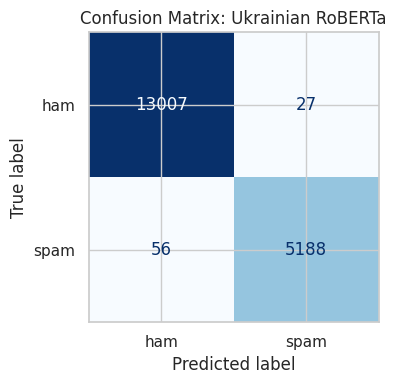

In [19]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    test_labels,
    test_preds,
    display_labels=["ham", "spam"],
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title("Confusion Matrix: Ukrainian RoBERTa")
plt.tight_layout()
plt.show()

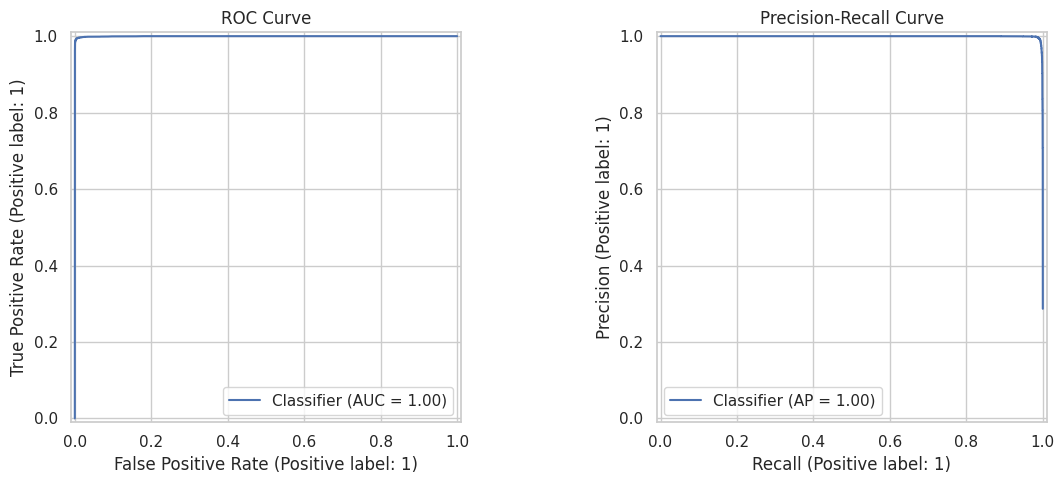

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(test_labels, test_probs[:, 1], ax=axes[0])
axes[0].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(test_labels, test_probs[:, 1], ax=axes[1])
axes[1].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

## 18. Збереження моделі та токенізатора

In [23]:
save_dir = OUTPUT_DIR / "ukr_roberta_spam_classifier"
save_dir.mkdir(exist_ok=True)

trainer.save_model(str(save_dir))
tokenizer.save_pretrained(str(save_dir))

print(f"Model and tokenizer saved to: {save_dir.resolve()}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to: /content/drive/MyDrive/spam_project/bert_artifacts/ukr_roberta_spam_classifier


## 19. Приклад inference

In [24]:
from transformers import pipeline

clf_pipe = pipeline(
    "text-classification",
    model=str(save_dir),
    tokenizer=str(save_dir),
    device=0 if torch.cuda.is_available() else -1,
)

examples = [
    "Вітаю! Ви виграли приз, терміново напишіть у приватні повідомлення.",
    "Дякую, інформація була корисною.",
    "Підписуйтесь на канал і переходьте за посиланням.",
    "Чи можна уточнити деталі по замовленню?"
]

predictions = clf_pipe(examples, truncation=True, max_length=MAX_LENGTH)
pd.DataFrame({"text": examples, "prediction": predictions})

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,text,prediction
0,"Вітаю! Ви виграли приз, терміново напишіть у п...","{'label': 'spam', 'score': 0.9999902248382568}"
1,"Дякую, інформація була корисною.","{'label': 'ham', 'score': 0.9999872446060181}"
2,Підписуйтесь на канал і переходьте за посиланням.,"{'label': 'spam', 'score': 0.9999877214431763}"
3,Чи можна уточнити деталі по замовленню?,"{'label': 'ham', 'score': 0.9987767338752747}"
